# Mushroom Classification Project

This project uses the Mushroom Classification dataset from Kaggle to predict whether a mushroom is edible or poisonous based on its physical characteristics.

The problem is treated as a binary classification task because each mushroom belongs to one of two classes: edible or poisonous.

## Project Goal

The goal of this project is to predict whether a mushroom is edible or poisonous from its listed physical features. I first look through the data, check for missing or unusual values, make a few plots and tables, clean the categorical columns, and then train classification models.

In [1]:
# Importing basic libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Importing KaggleHub for downloading the dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path)

Path to dataset files: /Users/samipbajgai/.cache/kagglehub/datasets/uciml/mushroom-classification/versions/1


In [3]:
# Listing files in the downloaded dataset folder
files = os.listdir(path)

# Displaying the available files
files

['mushrooms.csv']

In [4]:
# Creating the full path to the mushroom CSV file
csv_path = os.path.join(path, "mushrooms.csv")

# Loading the dataset into a pandas DataFrame
df = pd.read_csv(csv_path)

# Displaying the first five rows
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [5]:
# Checking the number of rows and columns
df.shape

(8124, 23)

In [6]:
# Checking the column names
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

## Initial Dataset Inspection

In this section, I inspect the structure of the dataset before building any machine learning model. This includes checking data types, missing values, duplicate rows, target classes, and the values inside each feature column.

In [7]:
# Checking basic dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [8]:
# Checking missing values in each column
missing_values = df.isnull().sum()

# Displaying missing value counts
missing_values

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [9]:
# Checking how many question mark values appear in each column
question_mark_counts = (df == "?").sum()

# Displaying question mark counts
question_mark_counts

class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

In [10]:
# Checking duplicate rows
duplicate_count = df.duplicated().sum()

# Displaying duplicate row count
duplicate_count

np.int64(0)

In [11]:
# Checking the target class counts
class_counts = df["class"].value_counts()

# Displaying target class counts
class_counts

class
e    4208
p    3916
Name: count, dtype: int64

In [12]:
# Checking target class percentages
class_percentages = df["class"].value_counts(normalize=True) * 100

# Displaying target class percentages
class_percentages

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64

In [13]:
# Checking the number of unique values in each column
unique_counts = df.nunique()

# Displaying unique value counts
unique_counts

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

In [14]:
# Displaying the unique values inside each column
for column in df.columns:
    print(column)
    print(df[column].unique())
    print()

class
<StringArray>
['p', 'e']
Length: 2, dtype: str

cap-shape
<StringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str

cap-surface
<StringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str

cap-color
<StringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str

bruises
<StringArray>
['t', 'f']
Length: 2, dtype: str

odor
<StringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str

gill-attachment
<StringArray>
['f', 'a']
Length: 2, dtype: str

gill-spacing
<StringArray>
['c', 'w']
Length: 2, dtype: str

gill-size
<StringArray>
['n', 'b']
Length: 2, dtype: str

gill-color
<StringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str

stalk-shape
<StringArray>
['e', 't']
Length: 2, dtype: str

stalk-root
<StringArray>
['e', 'c', 'b', 'r', '?']
Length: 5, dtype: str

stalk-surface-above-ring
<StringArray>
['s', 'f', 'k', 'y']
Length: 4, dtype: str

stalk-surface-below-ring
<StringArray>
['s', 

### Initial Inspection Notes

The dataset has 8124 rows and 23 columns. The target column is `class`, where `e` means edible and `p` means poisonous. All feature columns are categorical. Because the features are stored as letters instead of numbers, they must be encoded before training machine learning models.

The dataset does not use regular numeric measurements. Instead, each mushroom is described using physical characteristics such as cap shape, cap color, odor, gill size, stalk shape, ring type, population, and habitat.

### Missing Value Notes

The dataset does not contain regular missing values according to `df.isnull().sum()`. However, the `stalk-root` column contains 2480 question mark values. These question marks represent unknown or missing category values.

Because the dataset is categorical, I will treat `?` as its own category during preprocessing instead of dropping those rows. Dropping 2480 rows would remove a large part of the dataset.

In [15]:
# Building a feature summary table
feature_table = pd.DataFrame({
    "Feature": [
        "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
        "gill-attachment", "gill-spacing", "gill-size", "gill-color",
        "stalk-shape", "stalk-root", "stalk-surface-above-ring",
        "stalk-surface-below-ring", "stalk-color-above-ring",
        "stalk-color-below-ring", "veil-color", "ring-number",
        "ring-type", "spore-print-color", "population", "habitat"
    ],
    "Type": ["Categorical"] * 21,
    "Unique Values": [6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,4,3,5,9,6,7],
    "Missing (?)": [0,0,0,0,0,0,0,0,0,0,2480,0,0,0,0,0,0,0,0,0,0],
    "Notes": [
        "b,c,f,k,s,x", "f,g,s,y", "b,c,e,g,n,p,r,u,w,y", "t/f", 
        "Strong predictor — many odors are 100% one class",
        "a/f", "c/w", "b/n — narrow gill linked to poisonous", 
        "12 categories", "e/t", 
        "? replaced with 'missing' — 2480 rows affected",
        "s,f,k,y", "s,f,y,k", "9 colors", "9 colors",
        "w,n,o,y", "o,t,n", "e,f,l,n,p", "9 colors",
        "a,c,n,s,v,y", "d,g,l,m,p,u,w"
    ]
})

feature_table

,Feature,Type,Unique Values,Missing (?),Notes
0,cap-shape,Categorical,6,0,"b,c,f,k,s,x"
1,cap-surface,Categorical,4,0,"f,g,s,y"
2,cap-color,Categorical,10,0,"b,c,e,g,n,p,r,u,w,y"
3,bruises,Categorical,2,0,t/f
4,odor,Categorical,9,0,Strong predictor — many odors are 100% one class
5,gill-attachment,Categorical,2,0,a/f
6,gill-spacing,Categorical,2,0,c/w
7,gill-size,Categorical,2,0,b/n — narrow gill linked to poisonous
8,gill-color,Categorical,12,0,12 categories
9,stalk-shape,Categorical,2,0,e/t


Stalk-root is the only feature with missing values (encoded as ?). veil-type has only 1 unique value so it'll be dropped.

## Data Visualization

In this section, I use simple visualizations to understand the target classes and compare important categorical features against the mushroom class. These plots help show which features may be useful for classification.

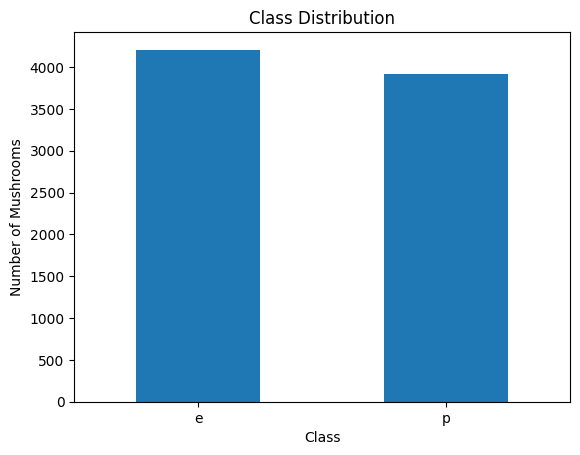

In [16]:
# Plotting the target class distribution
class_counts.plot(kind="bar")

# Adding plot labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)


plt.savefig("../images/class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

The class distribution is close to balanced. There are 4208 edible mushrooms and 3916 poisonous mushrooms. Because the two classes are similar in size, accuracy is a reasonable metric, but confusion matrix results are still needed.

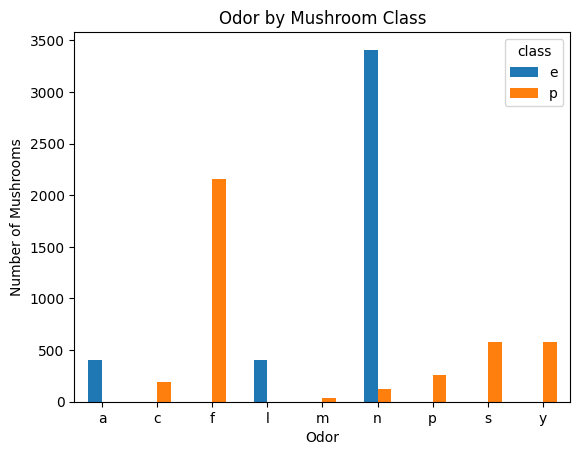

In [17]:
# Creating a table of odor values by class
odor_table = pd.crosstab(df["odor"], df["class"])

# Plotting odor counts by class
odor_table.plot(kind="bar")

plt.title("Odor by Mushroom Class")
plt.xlabel("Odor")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

plt.savefig("../images/odor_by_class.png", bbox_inches="tight", dpi=150)
plt.show()

Odor appears to be strongly related to mushroom class. Some odor categories are mostly edible, while others are mostly poisonous. This suggests that odor may be an important feature for the classification model.

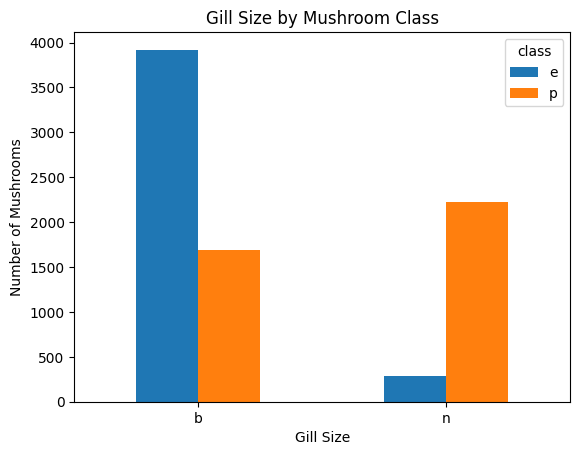

In [18]:
# Creating a table of gill size values by class
gill_size_table = pd.crosstab(df["gill-size"], df["class"])

# Plotting gill size counts by class
gill_size_table.plot(kind="bar")

# Adding plot labels
plt.title("Gill Size by Mushroom Class")
plt.xlabel("Gill Size")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

# Displaying the plot
plt.show()

Gill size also shows separation between edible and poisonous mushrooms. This feature may help the model distinguish between the two target classes.

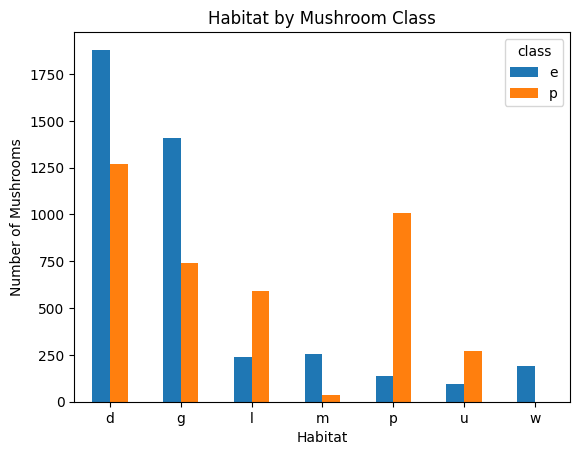

In [19]:
# Creating a table of habitat values by class
habitat_table = pd.crosstab(df["habitat"], df["class"])

# Plotting habitat counts by class
habitat_table.plot(kind="bar")

# Adding plot labels
plt.title("Habitat by Mushroom Class")
plt.xlabel("Habitat")
plt.ylabel("Number of Mushrooms")
plt.xticks(rotation=0)

# Displaying the plot
plt.show()

Habitat has several categories with different class patterns. It may not separate the classes as strongly as odor, but it still provides useful information for the model.

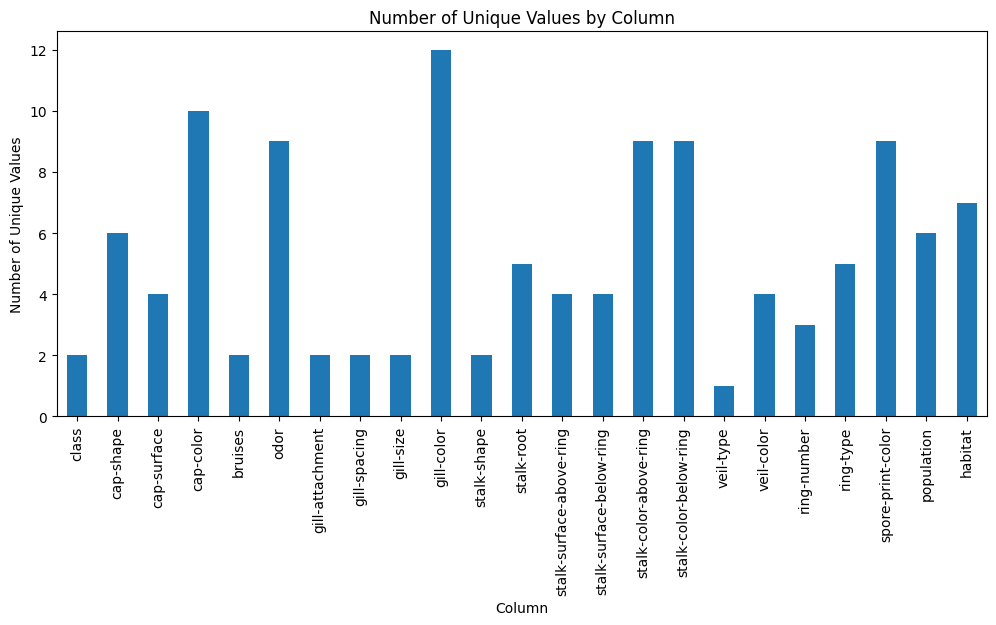

In [20]:
# Plotting number of unique values in each column
unique_counts.plot(kind="bar", figsize=(12, 5))

# Adding plot labels
plt.title("Number of Unique Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Unique Values")
plt.xticks(rotation=90)

# Displaying the plot
plt.show()

All columns are categorical, but they do not all have the same number of categories. The `veil-type` column has only one unique value, so it does not help separate edible and poisonous mushrooms. I will remove it before modeling because it has no variation.

In [21]:
# Creating a function for checking class percentages inside a categorical feature
def show_class_percentages(column):
    # Counting class values for each category
    count_table = pd.crosstab(df[column], df["class"])
    
    # Computing row percentages
    percent_table = pd.crosstab(df[column], df["class"], normalize="index") * 100
    
    # Displaying count and percentage tables
    print("Count table for", column)
    display(count_table)
    
    print("Percentage table for", column)
    display(percent_table.round(2))

In [22]:
# Checking class percentages for important categorical features
show_class_percentages("odor")
show_class_percentages("gill-size")
show_class_percentages("cap-shape")
show_class_percentages("habitat")

Count table for odor


class,e,p
odor,,
a,400,0
c,0,192
f,0,2160
l,400,0
m,0,36
n,3408,120
p,0,256
s,0,576
y,0,576


Percentage table for odor


class,e,p
odor,,
a,100.0,0.0
c,0.0,100.0
f,0.0,100.0
l,100.0,0.0
m,0.0,100.0
n,96.6,3.4
p,0.0,100.0
s,0.0,100.0
y,0.0,100.0


Count table for gill-size


...

class,e,p
cap-shape,,
b,89.38,10.62
c,0.00,100.00
f,50.63,49.37
k,27.54,72.46
s,100.00,0.00
x,53.28,46.72


Count table for habitat


class,e,p
habitat,,
d,1880,1268
g,1408,740
l,240,592
m,256,36
p,136,1008
u,96,272
w,192,0


Percentage table for habitat


class,e,p
habitat,,
d,59.72,40.28
g,65.55,34.45
l,28.85,71.15
m,87.67,12.33
p,11.89,88.11
u,26.09,73.91
w,100.00,0.00


The tables confirm some patterns that are hard to read exactly from the bar plots. For example, some odor categories are almost completely edible or poisonous. This makes odor a strong feature for the model.

## Data Cleaning and Preparation for Machine Learning

In this section, I prepare the categorical mushroom dataset for machine learning. The target column is converted into numeric labels, the feature columns are one-hot encoded, and the data is split into training, validation, and testing samples.

In [23]:
# Creating a copy of the original DataFrame for cleaning
df_clean = df.copy()

# Displaying the first few rows of the cleaned copy
df_clean.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [24]:
# Replacing question marks with an explicit missing category
df_clean["stalk-root"] = df_clean["stalk-root"].replace("?", "missing")

# Checking the updated values in stalk-root
df_clean["stalk-root"].value_counts()

stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64

The main data issue is in `stalk-root`. It uses `?` instead of a blank value. Since this appears many times, I do not drop those rows. I keep them by changing `?` to `missing`.

In [25]:
# Dropping veil-type because it has only one unique value
df_clean = df_clean.drop(columns=["veil-type"])

# Checking the new shape after dropping the column
df_clean.shape

(8124, 22)

I removed `veil-type` because every row had the same value. A feature with only one value cannot help a classification model.

In [26]:
# Separating the target column from the feature columns
X = df_clean.drop(columns=["class"])
y = df_clean["class"]

# Checking feature and target shapes
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8124, 21)
Target shape: (8124,)


In [27]:
# Converting target labels into numeric values
y = y.map({"e": 0, "p": 1})

# Checking numeric target counts
y.value_counts()

class
0    4208
1    3916
Name: count, dtype: int64

The target labels were converted into numeric values. Edible mushrooms were coded as 0, and poisonous mushrooms were coded as 1. I used poisonous as the positive class because it is the more important class to identify correctly.

In [28]:
# One-hot encoding the categorical feature columns
X_encoded = pd.get_dummies(X, dtype=int)

# Checking the encoded feature shape
X_encoded.shape

(8124, 116)

In [29]:
# Displaying the first few rows of the encoded features
X_encoded.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


All feature columns were categorical, so I used one-hot encoding to convert them into numeric columns. This creates separate 0/1 columns for each category value.

In [30]:
# Importing train_test_split
from sklearn.model_selection import train_test_split

In [31]:
# Splitting data into training plus temporary sample and final testing sample
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Splitting the training sample again into training and validation samples
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

# Checking the final split sizes
print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)
print("Testing target:", y_test.shape)

Training features: (4874, 116)
Validation features: (1625, 116)
Testing features: (1625, 116)
Training target: (4874,)
Validation target: (1625,)
Testing target: (1625,)


The data was split into training, validation, and testing samples. The training sample is used to fit the models. The validation sample is used to compare model performance. The testing sample is kept separate for a final local performance check.

In [32]:
# Checking class balance in the training sample
print("Training class balance")
print(y_train.value_counts(normalize=True) * 100)

# Checking class balance in the validation sample
print("\nValidation class balance")
print(y_val.value_counts(normalize=True) * 100)

# Checking class balance in the testing sample
print("\nTesting class balance")
print(y_test.value_counts(normalize=True) * 100)

Training class balance
class
0    51.784982
1    48.215018
Name: proportion, dtype: float64

Validation class balance
class
0    51.815385
1    48.184615
Name: proportion, dtype: float64

Testing class balance
class
0    51.815385
1    48.184615
Name: proportion, dtype: float64


## Machine Learning

In this section, I train three classification models. I start with Logistic Regression as a baseline model. Then I train a Decision Tree and a Random Forest to compare against the baseline.

The target is binary: edible mushrooms are coded as 0, and poisonous mushrooms are coded as 1.

In [33]:
# Importing classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Importing evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

### Baseline Model: Logistic Regression

I use Logistic Regression as the baseline model. This gives a simple first result to compare against the tree-based models.

In [34]:
# Creating the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Training the Logistic Regression model
logistic_model.fit(X_train, y_train)

# Predicting validation labels
logistic_val_predictions = logistic_model.predict(X_val)

# Computing validation accuracy
logistic_accuracy = accuracy_score(y_val, logistic_val_predictions)

# Displaying validation accuracy
logistic_accuracy

1.0

In [35]:
# Displaying the Logistic Regression classification report
print(classification_report(
    y_val,
    logistic_val_predictions,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### Decision Tree Model

I use a Decision Tree because it works well with tabular classification problems and is easier to interpret than many other models.

In [36]:
# Creating the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

# Training the Decision Tree model
tree_model.fit(X_train, y_train)

# Predicting validation labels
tree_val_predictions = tree_model.predict(X_val)

# Computing validation accuracy
tree_accuracy = accuracy_score(y_val, tree_val_predictions)

# Displaying validation accuracy
tree_accuracy

1.0

In [37]:
# Displaying the Decision Tree classification report
print(classification_report(
    y_val,
    tree_val_predictions,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### Random Forest Model

I use a Random Forest as the stronger model. It combines multiple decision trees and often performs well on tabular data.

In [38]:
# Creating the Random Forest model
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training the Random Forest model
forest_model.fit(X_train, y_train)

# Predicting validation labels
forest_val_predictions = forest_model.predict(X_val)

# Computing validation accuracy
forest_accuracy = accuracy_score(y_val, forest_val_predictions)

# Displaying validation accuracy
forest_accuracy

1.0

In [39]:
# Displaying the Random Forest classification report
print(classification_report(
    y_val,
    forest_val_predictions,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### Validation Performance Comparison

I compare the models using accuracy, precision, recall, and F1 score. Recall is especially important here because missing a poisonous mushroom would be more serious than incorrectly warning about an edible mushroom.

In [40]:
# Creating a simple majority-class baseline
majority_class = y_train.mode()[0]

# Predicting the majority class for every validation row
majority_val_predictions = np.full(len(y_val), majority_class)

# Creating a list of model names and predictions
model_predictions = [
    ["Majority Class Baseline", majority_val_predictions],
    ["Logistic Regression", logistic_val_predictions],
    ["Decision Tree", tree_val_predictions],
    ["Random Forest", forest_val_predictions]
]

# Initializing an empty list for model results
results = []

# Computing metrics for each model
for model_name, predictions in model_predictions:
    # Computing model metrics
    accuracy = accuracy_score(y_val, predictions)
    precision = precision_score(y_val, predictions, zero_division=0)
    recall = recall_score(y_val, predictions, zero_division=0)
    f1 = f1_score(y_val, predictions, zero_division=0)
    
    # Saving model results
    results.append([model_name, accuracy, precision, recall, f1])

# Creating a DataFrame for comparison
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

# Displaying model comparison
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Majority Class Baseline,0.518154,0.0,0.0,0.0
1,Logistic Regression,1.000000,1.0,1.0,1.0
2,Decision Tree,1.000000,1.0,1.0,1.0
3,Random Forest,1.000000,1.0,1.0,1.0


The majority-class baseline only predicts the most common class from the training sample. Its performance is much lower than the trained models. This shows that the 1.0 validation accuracy is not coming from class imbalance.

All three trained models reached perfect validation performance. This is unusual in many real-world datasets, but it makes sense here because the mushroom dataset is clean, categorical, and highly separable.

### Sanity Checks for Perfect Accuracy

Because all trained models reached 1.0 validation accuracy, I checked for common causes of misleading performance. I checked that the target column was not included in the encoded feature set and that the train, validation, and test samples did not overlap.

In [41]:
# Checking that the target column was not included in the encoded features
target_leakage_columns = [
    column for column in X_encoded.columns 
    if column.startswith("class")
]

# Displaying possible target leakage columns
target_leakage_columns

[]

In [42]:
# Checking for overlap between training, validation, and testing row indexes
train_val_overlap = len(set(X_train.index).intersection(set(X_val.index)))
train_test_overlap = len(set(X_train.index).intersection(set(X_test.index)))
val_test_overlap = len(set(X_val.index).intersection(set(X_test.index)))

# Displaying overlap counts
print("Train-validation overlap:", train_val_overlap)
print("Train-test overlap:", train_test_overlap)
print("Validation-test overlap:", val_test_overlap)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


The sanity checks did not show target leakage or row overlap. The target column was not included in the encoded features, and the train, validation, and test samples used separate rows. This supports the idea that the high performance is caused by strong patterns in the mushroom features.

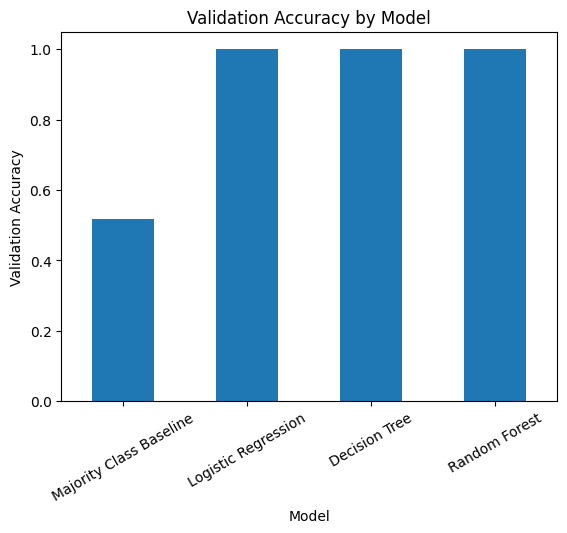

In [43]:
# Plotting validation accuracy for each model
results_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

# Adding plot labels
plt.title("Validation Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=30)

plt.savefig("../images/validation_accuracy.png", bbox_inches="tight", dpi=150)
plt.show()

## Final Testing Performance

After comparing the models on the validation sample, I use the Random Forest model for the final testing sample. The testing sample was held out earlier and was not used to train or compare the models.

In [44]:
# Predicting labels for the final testing sample
forest_test_predictions = forest_model.predict(X_test)

# Computing final testing accuracy
forest_test_accuracy = accuracy_score(y_test, forest_test_predictions)

# Displaying final testing accuracy
forest_test_accuracy

1.0

In [45]:
# Displaying the Random Forest classification report on the testing sample
print(classification_report(
    y_test,
    forest_test_predictions,
    target_names=["edible", "poisonous"]
))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [46]:
# Creating the confusion matrix for the testing sample
forest_test_confusion = confusion_matrix(y_test, forest_test_predictions)

# Displaying the testing confusion matrix
forest_test_confusion

array([[842,   0],
       [  0, 783]])

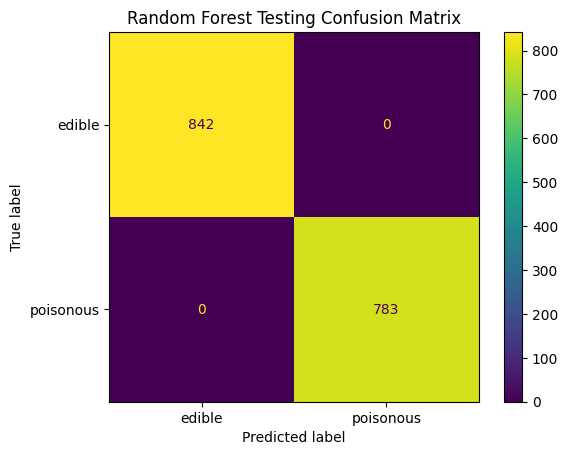

In [47]:
# Plotting the Random Forest testing confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_test_predictions,
    display_labels=["edible", "poisonous"]
)

# Adding plot title
plt.title("Random Forest Testing Confusion Matrix")

plt.savefig("../images/testing_confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

The Random Forest model also reached perfect performance on the held-out testing sample. Since the target was not included in the features and the testing rows did not overlap with the training or validation rows, this result appears to come from the strong relationship between the mushroom features and the class label.

## Feature Importance

I use the Random Forest feature importance values to see which encoded mushroom features were most useful for prediction. Since the original columns were one-hot encoded, each importance value belongs to one category from a feature column.

In [48]:
# Creating a DataFrame of Random Forest feature importances
importance_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": forest_model.feature_importances_
})

# Sorting features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Displaying the top 15 most important encoded features
importance_df.head(15)

,Feature,Importance
27,odor_n,0.080155
57,stalk-surface-above-ring_k,0.072638
35,gill-size_b,0.070718
24,odor_f,0.065301
37,gill-color_b,0.043396
36,gill-size_n,0.043391
95,spore-print-color_h,0.039222
61,stalk-surface-below-ring_k,0.036998
93,ring-type_p,0.032209
91,ring-type_l,0.032133


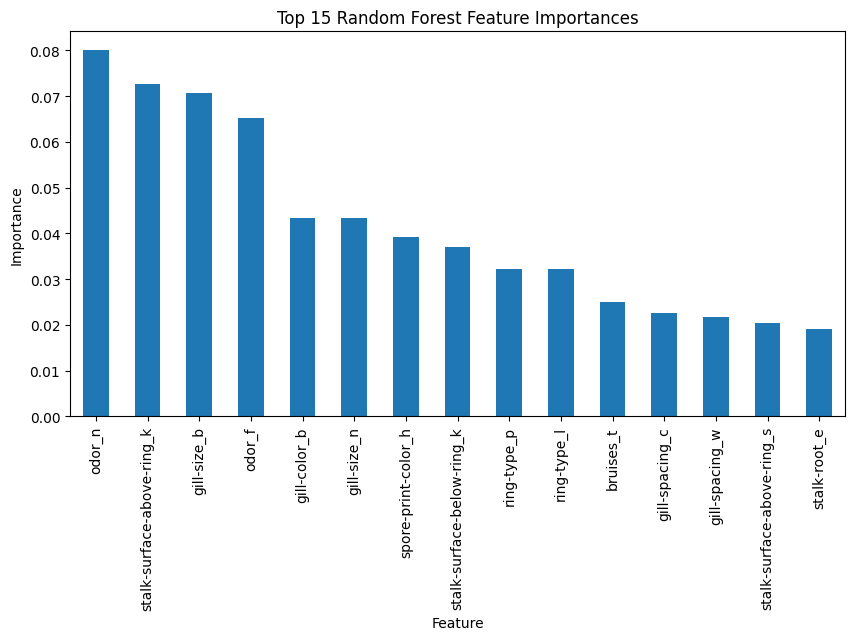

In [49]:
# Plotting the top 15 feature importances
importance_df.head(15).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

# Adding plot labels
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=90)

# Displaying the plot
plt.show()

The most important encoded features mostly come from physical mushroom characteristics that showed clear class patterns during exploration. This supports the earlier visualizations, especially the features where edible and poisonous mushrooms had different category patterns.

## Conclusion

This project built a complete classification workflow for the Mushroom Classification dataset. The data was inspected, cleaned, visualized, encoded, split into training, validation, and testing samples, and then used to train classification models.

The main data issue was the `?` values in `stalk-root`. I treated those values as a `missing` category instead of dropping the rows. I also removed `veil-type` because it had only one unique value.

The majority-class baseline performed much worse than the trained models. Logistic Regression, Decision Tree, and Random Forest all reached perfect validation accuracy. The Random Forest model also reached perfect testing accuracy. I checked for target leakage and row overlap, and those checks did not show problems.

The result should still be interpreted carefully. This dataset is clean and highly separable, so perfect performance here does not mean the same model would always perform perfectly on new mushroom data.